# Prodigy InfoTech Internship Task 2

In [139]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [140]:
# load the titanic dataset
titanic_data=pd.read_csv(r"C:\Users\LENOVO\Downloads\Titanic\Titanic-Dataset.csv")
print(titanic_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [141]:
# number of rows and columns
titanic_data.shape

(891, 12)

In [142]:
# data columns
titanic_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [143]:
# statistical analysis of the dataset
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [144]:
# looking for null values in the dataset
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [145]:
titanic_data['Age'].isnull().sum()

177

In [146]:
# replacing the null values in age column with median values
titanic_data['Age'].fillna(titanic_data['Age'].median(),inplace=True)

In [147]:
titanic_data['Age'].isnull().sum()

0

In [148]:
titanic_data['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

In [149]:
titanic_data['Cabin'].isnull().sum()

687

In [150]:
# Dropping the cabin column since it has too many NaN values
titanic_data.drop(columns=['Cabin'],inplace=True)

In [151]:
titanic_data['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [152]:
titanic_data['Embarked'].isnull().sum()

2

In [153]:
# replacing the embarked column NaN values with mode values
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0],inplace=True)

In [154]:
titanic_data['Embarked'].isnull().sum()

0

In [155]:
# Converting these columns to category type 
titanic_data['Sex']=titanic_data['Sex'].astype('category')
titanic_data['Embarked']=titanic_data['Embarked'].astype('category')

# Univariate Analysis (Basic EDA)

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

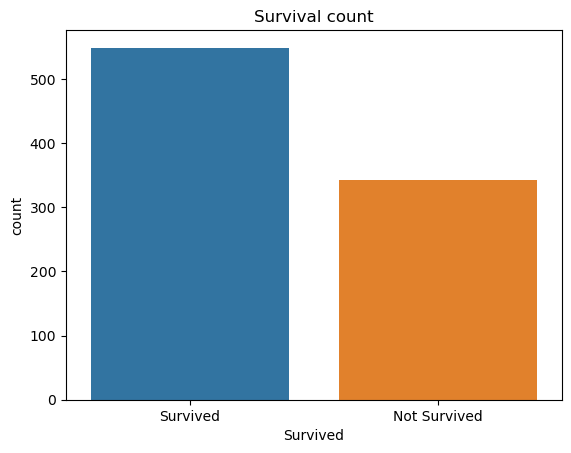

In [157]:
# Survival Count countplot
sns.countplot(x='Survived',data=titanic_data)
plt.title('Survival count')
plt.xticks([0,1],['Survived','Not Survived'])
plt.show()

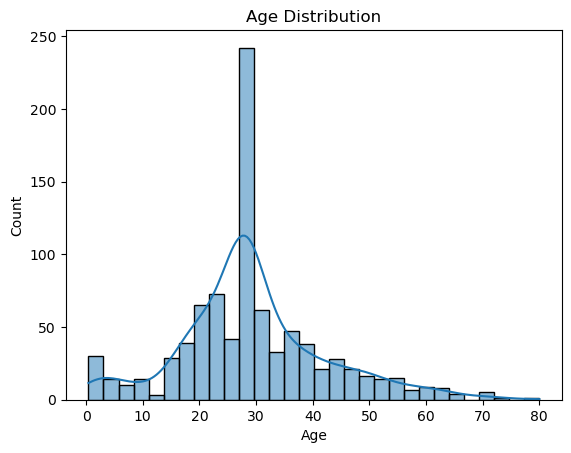

In [158]:
# Age Distribution Histogram Plot
sns.histplot(titanic_data['Age'],bins=30,kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

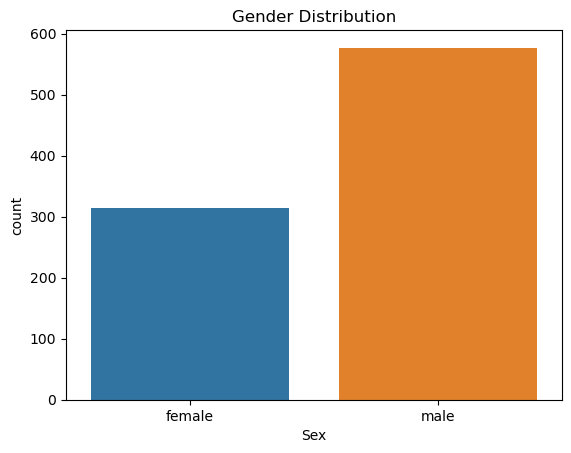

In [159]:
# Gender Distribution countplot
sns.countplot(x='Sex',data=titanic_data)
plt.title('Gender Distribution')
plt.show()

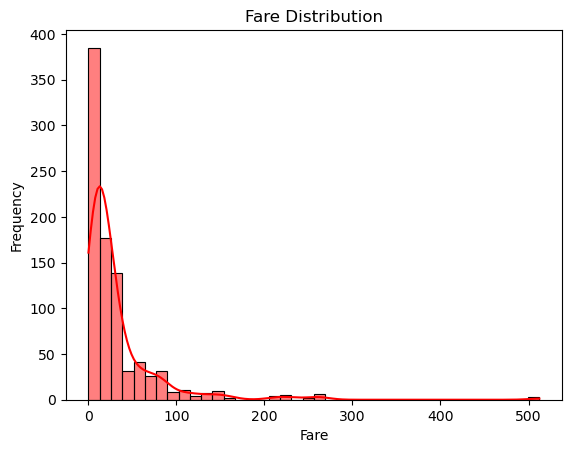

In [160]:
# Fare Distribution Histogram Plot
sns.histplot(titanic_data['Fare'],bins=40,kde=True,color='Red')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

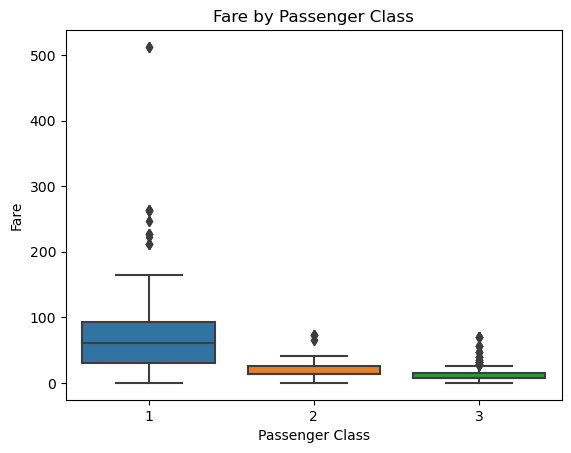

In [161]:
# Boxplot of Fare by Passenger Class
sns.boxplot(x='Pclass',y='Fare',data=titanic_data)
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

# Bivariate Analysis (Relationships between variables)

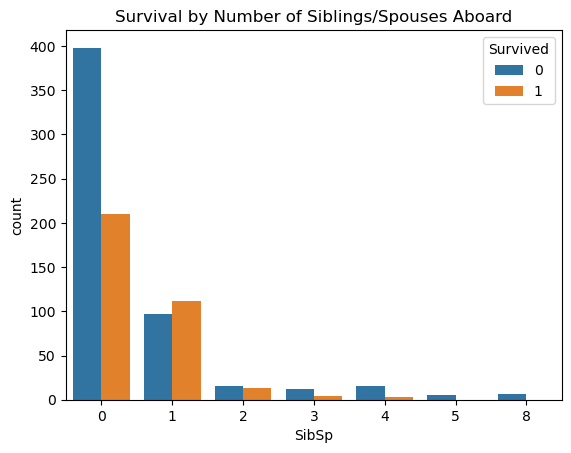

In [162]:
# Countplot of Survival by Number of Siblings/Spouses Aboard
sns.countplot(x='SibSp',hue='Survived',data=titanic_data)
plt.title('Survival by Number of Siblings/Spouses Aboard')
plt.show()

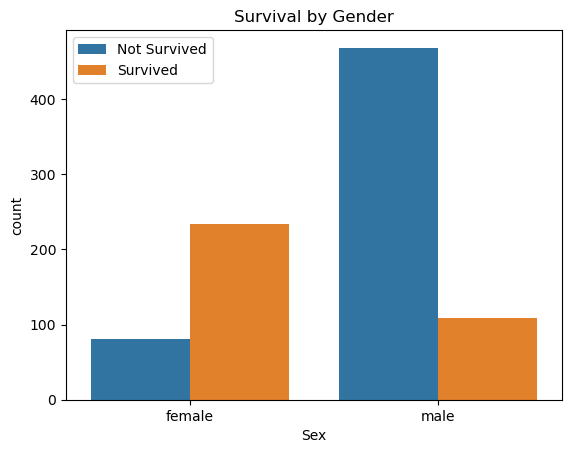

In [163]:
# Countplot of Survival by Gender
sns.countplot(x='Sex',hue='Survived',data=titanic_data)
plt.title('Survival by Gender')
plt.legend(labels=['Not Survived','Survived'])
plt.show()

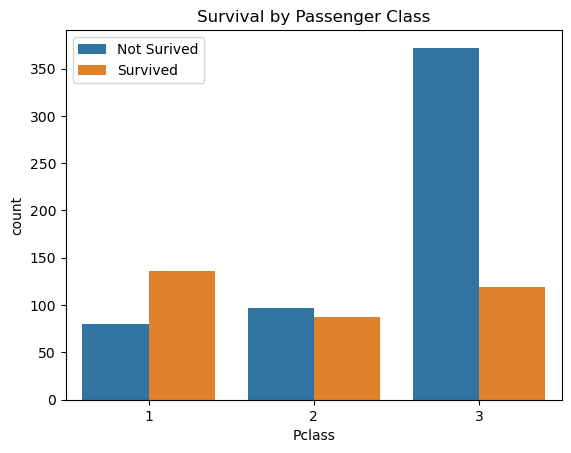

In [164]:
# Countplot of Survival by Passenger Class
sns.countplot(x='Pclass',hue='Survived',data=titanic_data)
plt.title('Survival by Passenger Class')
plt.legend(labels=['Not Surived','Survived'])
plt.show()

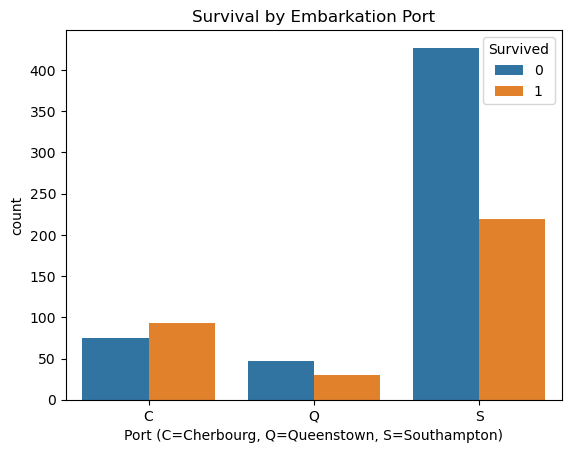

In [165]:
# countplot of Survival by Embarkation Port
sns.countplot(x='Embarked',hue='Survived',data=titanic_data)
plt.title('Survival by Embarkation Port')
plt.xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.show()

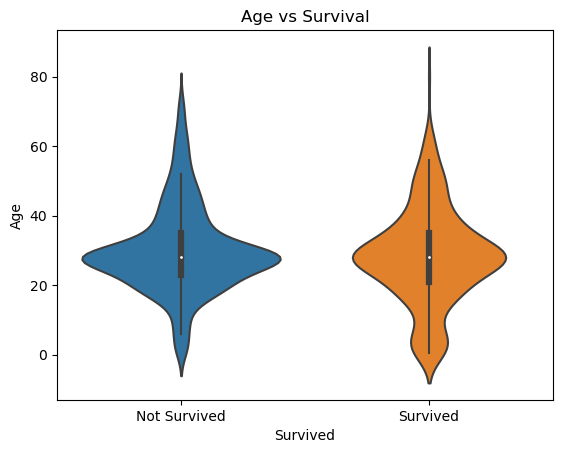

In [166]:
# Violinplot for comparing age and survivors
sns.violinplot(x='Survived',y='Age',data=titanic_data)
plt.title('Age vs Survival')
plt.xticks([0,1],['Not Survived','Survived'])
plt.show()

# Multivariate Analysis (Patterns and Trends)

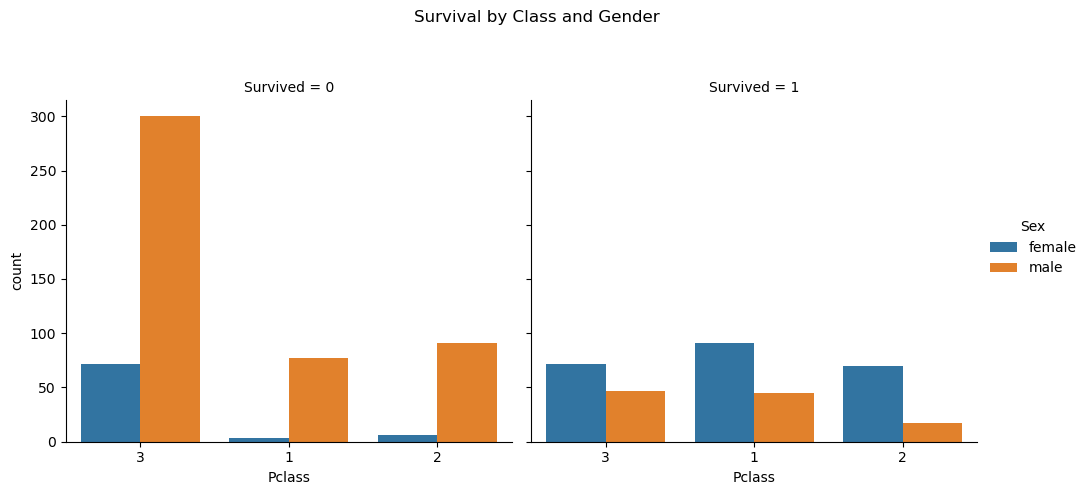

In [167]:
# We convert the Pclass column to categorical variable
# Catplot of Survival by class and gender
titanic_data['Pclass']=titanic_data['Pclass'].astype(str)
sns.catplot(x='Pclass',hue='Sex',col='Survived',data=titanic_data,kind='count')
plt.subplots_adjust(top=0.8)
plt.suptitle('Survival by Class and Gender')
plt.show()

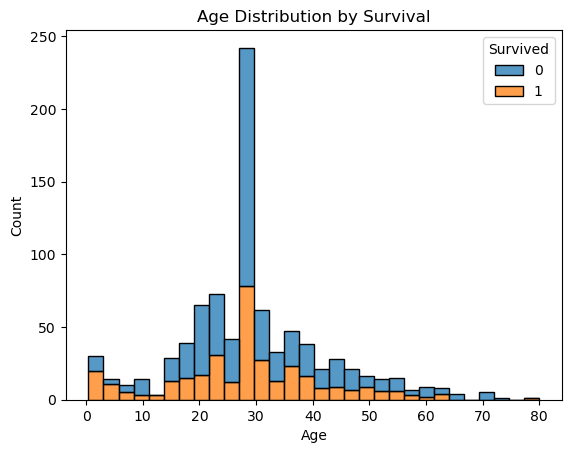

In [168]:
# Histogram Plot of Age Distribution by Survival
sns.histplot(data=titanic_data,x='Age',hue='Survived',multiple='stack',bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Heatmap : Correlation between Numerical Features

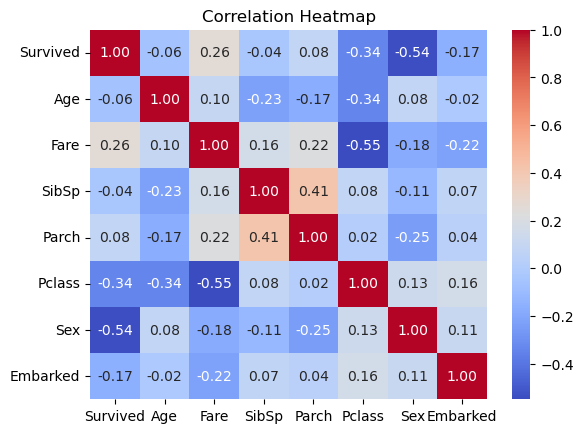

In [169]:
titanic_data_encoded=titanic_data.copy()
titanic_data_encoded['Sex']=titanic_data_encoded['Sex'].cat.codes
titanic_data_encoded['Embarked']=titanic_data_encoded['Embarked'].cat.codes
corr=titanic_data_encoded[['Survived','Age','Fare','SibSp','Parch','Pclass','Sex','Embarked']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()